In [1]:
"""
Aim: UMAP to confirm dataset annotated by Frederik
Author: Yike Xie
Date: 5th-Mar-2025
"""

'\nAim: UMAP to confirm dataset annotated by Frederik\nAuthor: Yike Xie\nDate: 5th-Mar-2025\n'

In [1]:
import utils

import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# load data
adata = sc.read_h5ad('../data/parse_snRNA_annotated_v3.h5ad')

In [3]:
# new obs columns: cell type and cell subtype
adata.obs['cell_type'] = adata.obs['annotation'].astype(str).replace(
    {'β': 'Endocrine',
     'α + γ + δ': 'Endocrine',
     'Acinar_0': 'Acinar', 
     'Acinar_1': 'Acinar', 
     'Acinar_2': 'Acinar', 
     'Acinar_5': 'Acinar',
    }
)

ct_order = ['Endocrine', 'Acinar', 'Ductal', 'Endothelial', 'Immune', 'Stellate',]
adata.obs['cell_type'] = adata.obs['cell_type'].astype(
    pd.CategoricalDtype(categories=ct_order, ordered=True)
)  # Set order

adata.obs['cell_subtype'] = adata.obs['annotation_subclustering_updated'].astype(str).replace(
    {'Quie. stellate': 'Quiescent stellate',
     'NaN': 'Unknown'
    }
)

cst_order = ['α', 'β', 'γ', 'δ',
             'Acinar_0', 'Acinar_1', 'Acinar_2', 
             'Ductal_0', 'Ductal_1', 'Ductal_2', 'Endothelial', 
             'Macrophages', 'Naiive B-cells', 'T-cells', 'Mast cells', 'Schwann', 
             'Activated stellate', 'Quiescent stellate', 
             'Doublets',
             'Unknown', ]

adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype(
    pd.CategoricalDtype(categories=cst_order, ordered=True)
)  # Set order

In [4]:
# get the number of cells in each cell type and subtype after removing doublets

df = adata.obs.groupby('cell_subtype')['cell_type'].value_counts().to_frame()

csts = adata.obs['cell_subtype'].cat.categories
clusters = adata.obs['cell_type'].cat.categories

df_n = pd.DataFrame(index=csts, columns=clusters)

for cst in csts:
    for cls in clusters:
        df_n.at[cst, cls] = df.loc[cst, cls][0]

/tmp/ipykernel_45081/2319682151.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby('cell_subtype')['cell_type'].value_counts().to_frame()
/tmp/ipykernel_45081/2319682151.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_n.at[cst, cls] = df.loc[cst, cls][0]


In [5]:
df_n

,Endocrine,Acinar,Ductal,Endothelial,Immune,Stellate
α,720,0,0,0,0,0
β,1171,0,0,0,0,0
γ,96,0,0,0,0,0
δ,116,0,0,0,0,0
Acinar_0,0,16716,0,0,0,0
Acinar_1,0,19658,0,0,0,0
Acinar_2,0,263,0,0,0,0
Ductal_0,0,0,3788,0,0,0
Ductal_1,0,0,4731,0,0,0
Ductal_2,0,0,7437,0,0,0


In [6]:
# check the expression of maker genes in 11 NaN cells
gene_list = [
    "GCG", "INS", "PPY", "SST", 
    "PECAM1", 
    "CD163", "IGHA1", "CD96", "KIT", "NRXN3", 
    "COL6A3", "RGS5",]

adata_nan = adata[adata.obs['cell_subtype'] == 'Unknown']

check_df = pd.DataFrame(
    adata_nan[:, gene_list].X.toarray(),
    index=adata_nan.obs_names,
    columns=gene_list
                       )

check_df

,GCG,INS,PPY,SST,PECAM1,CD163,IGHA1,CD96,KIT,NRXN3,COL6A3,RGS5
bc_wells,,,,,,,,,,,,
29_37_82,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
39_81_32,0.000000,0.0,0.0,0.0,0.756459,1.895157,0.0,0.00000,0.0,0.0,0.000000,0.000000
39_91_19,0.000000,0.0,0.0,0.0,1.577418,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.570124
39_96_44,0.000000,0.0,0.0,0.0,0.924842,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
07_77_60,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
44_80_32,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,1.492235,0.000000
39_75_35,0.000000,0.0,0.0,0.0,0.000000,1.722785,0.0,0.00000,0.0,0.0,0.000000,0.000000
07_81_19,0.000000,0.0,0.0,0.0,0.924530,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
44_26_06,1.380221,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000


In [7]:
# validate the annotation
annotate_dict = {
    '29_37_82': 'Unknown', 
    '39_81_32': 'Doublets', 
    '39_91_19': 'Doublets', 
    '39_96_44': 'Endothelial', 
    '07_77_60': 'Unknown', 
    '44_80_32': 'Activated stellate',   
    '39_75_35': 'Macrophages', 
    '07_81_19': 'Endothelial', 
    '44_26_06': 'α', 
    '44_64_56': 'Doublets', 
    '44_93_46': 'Unknown'
}

adata_nan.obs['cell_subtype'] = adata_nan.obs['cell_subtype'].astype(str)

for cell, cst in annotate_dict.items():
    adata_nan.obs.loc[cell, 'cell_subtype'] = cst

adata_nan.obs[['cell_type', 'cell_subtype']]

/tmp/ipykernel_45081/3280478402.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_nan.obs['cell_subtype'] = adata_nan.obs['cell_subtype'].astype(str)


,cell_type,cell_subtype
bc_wells,,
29_37_82,Immune,Unknown
39_81_32,Immune,Doublets
39_91_19,Endothelial,Doublets
39_96_44,Endothelial,Endothelial
07_77_60,Endothelial,Unknown
44_80_32,Stellate,Activated stellate
39_75_35,Immune,Macrophages
07_81_19,Endothelial,Endothelial
44_26_06,Endocrine,α


In [8]:
# annotate these 11 cells to adata
for cell, cst in annotate_dict.items():
    adata.obs.loc[cell, 'cell_subtype'] = cst

In [9]:
# check the annotation again
df = adata.obs.groupby('cell_subtype')['cell_type'].value_counts().to_frame()

csts = adata.obs['cell_subtype'].cat.categories
clusters = adata.obs['cell_type'].cat.categories

df_n = pd.DataFrame(index=csts, columns=clusters)

for cst in csts:
    for cls in clusters:
        df_n.at[cst, cls] = df.loc[cst, cls][0]
        
df_n

/tmp/ipykernel_45081/3088521149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby('cell_subtype')['cell_type'].value_counts().to_frame()
/tmp/ipykernel_45081/3088521149.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_n.at[cst, cls] = df.loc[cst, cls][0]


,Endocrine,Acinar,Ductal,Endothelial,Immune,Stellate
α,721,0,0,0,0,0
β,1171,0,0,0,0,0
γ,96,0,0,0,0,0
δ,116,0,0,0,0,0
Acinar_0,0,16716,0,0,0,0
Acinar_1,0,19658,0,0,0,0
Acinar_2,0,263,0,0,0,0
Ductal_0,0,0,3788,0,0,0
Ductal_1,0,0,4731,0,0,0
Ductal_2,0,0,7437,0,0,0


In [12]:
# filter out doublets and unknown cells
adata_filter = adata[~ adata.obs['cell_subtype'].isin(['Doublets', 'Unknown'])]

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

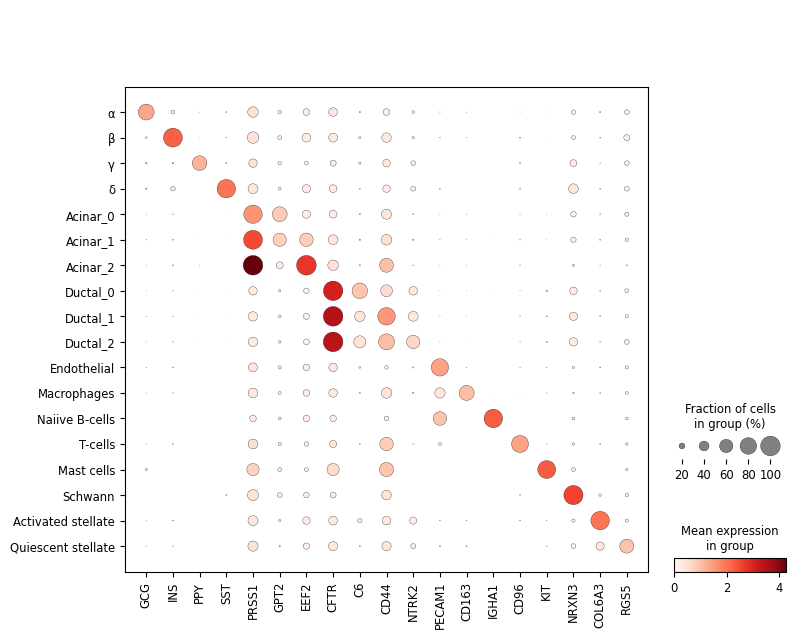

In [13]:
# rename NaN, what they should be

marker_genes = ["GCG", "INS", "PPY", "SST", # endocrine
                
                "PRSS1", "GPT2", "EEF2",  # acinar
                
                'CFTR', "C6",  "CD44", "NTRK2", # ductal
                
                "PECAM1", # endothelial
                
                "CD163", # macrophages
                "IGHA1", # naive B cells
                "CD96", # T cells
                "KIT", # mast cells
                "NRXN3", # schwann
                
                "COL6A3", # activated stellate
                "RGS5", # quiescent stellate
                ]

sc.pl.dotplot(adata_filter, 
              var_names = marker_genes, 
              groupby = 'cell_subtype', show = False)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


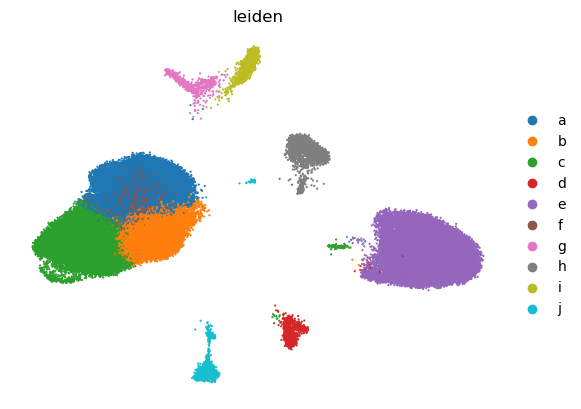

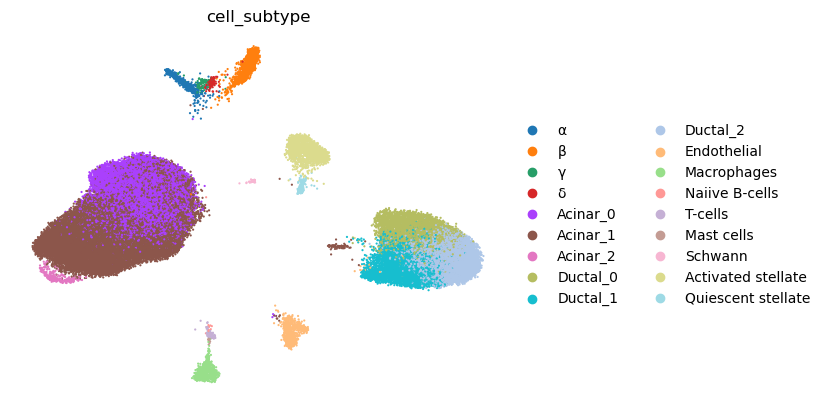

In [14]:
for antt in ['leiden', 'cell_subtype']:
    sc.pl.umap(adata_filter, color = antt,
               show = False, frameon=False, 
               use_raw = False, legend_loc = 'right margin', size = 10)

In [16]:
# save the data without doublets and unknown cells
adata_filter.write_h5ad('../data/parse_snRNA_annotated_YK.h5ad')

In [ ]:
adata_raw = adata_filter.copy()

# load raw counts
adata_raw.X = adata_raw.layers['counts']

# only keep wanted metadata
adata_raw.obs = adata_raw.obs[[
    'sample', 'doublet_score', 
    'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 
    'HbA1c (%)', 'HbA1c', 
    'Age', 'CIT (hours)', 'Cohort', 'RIN', 
    'Nuclei isolation', 'group', 'cell_type', 'cell_subtype']
]

adata_raw.uns = {}        # Clear `uns`
adata_raw.varm = {}       # Clear `varm`
adata_raw.layers = {}     # Clear `layers`
adata_raw.obsp = {}       # Clear `obsp`

adata_raw.write_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')